# Diabetes Prediction — LightGBM + XAI

| | |
|---|---|
| **Student** | Abdallah Saed — 202201933 |
| **Dataset** | BRFSS 2015 Diabetes Health Indicators |
| **Model** | LightGBM |
| **XAI** | SHAP · LIME · Permutation Importance · PDP + ICE |

## 1. Install and Import Libraries

In [ ]:
!pip install lightgbm shap lime scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score,
    fbeta_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import shap
import lime
import lime.lime_tabular

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='Set2')

print(f"LightGBM: {lgb.__version__}  |  SHAP: {shap.__version__}")
print("All libraries imported.")

LightGBM: 4.6.0  |  SHAP: 0.51.0
All libraries imported.


## 2. Load Dataset

In [ ]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Shape         : {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum()}")
df.head()

Shape         : (253680, 22)
Missing values: 0
Duplicates    : 24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Exploratory Data Analysis

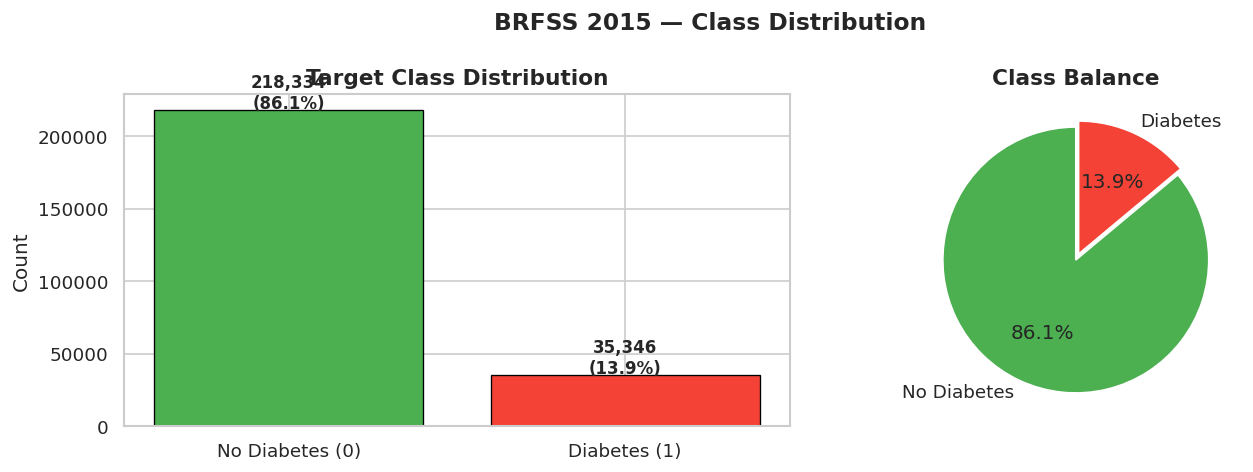

Class ratio: 6.18:1  (imbalanced — SMOTE will be applied)


In [ ]:
counts = df['Diabetes_binary'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('BRFSS 2015 — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Class ratio: {counts[0]/counts[1]:.2f}:1  (imbalanced — SMOTE will be applied)")

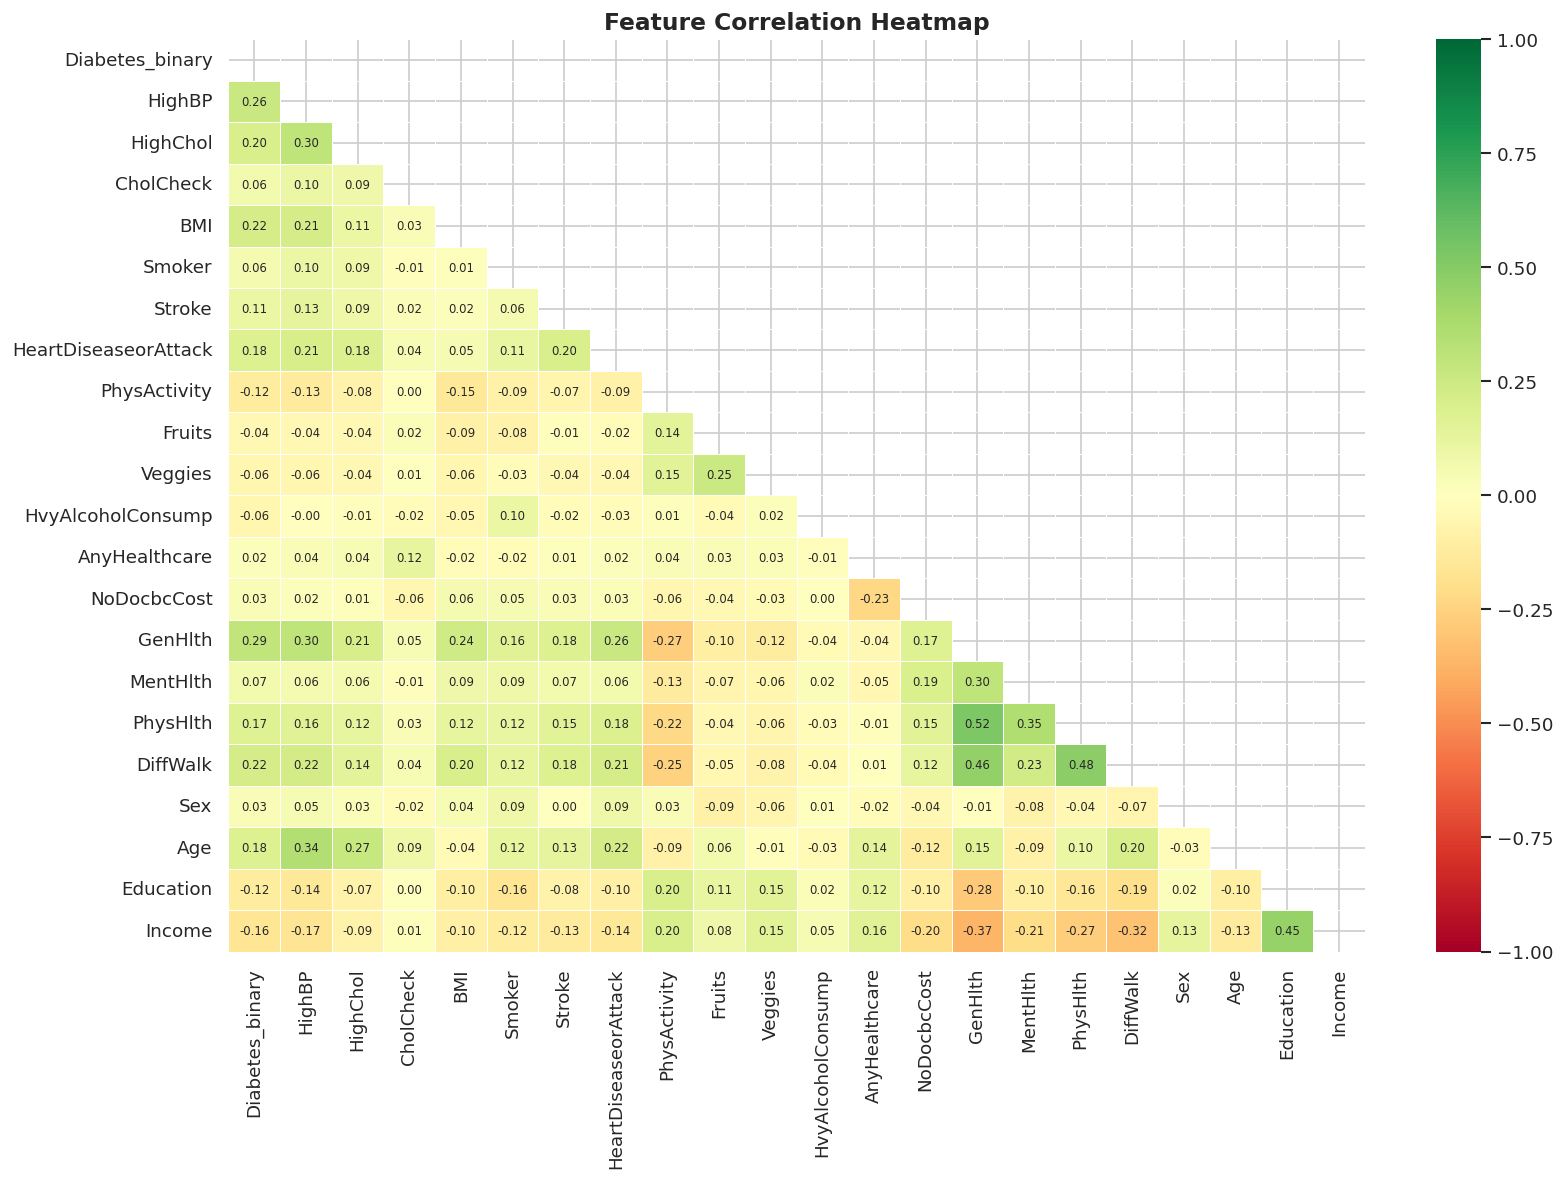

In [ ]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, annot_kws={'size': 7}, center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

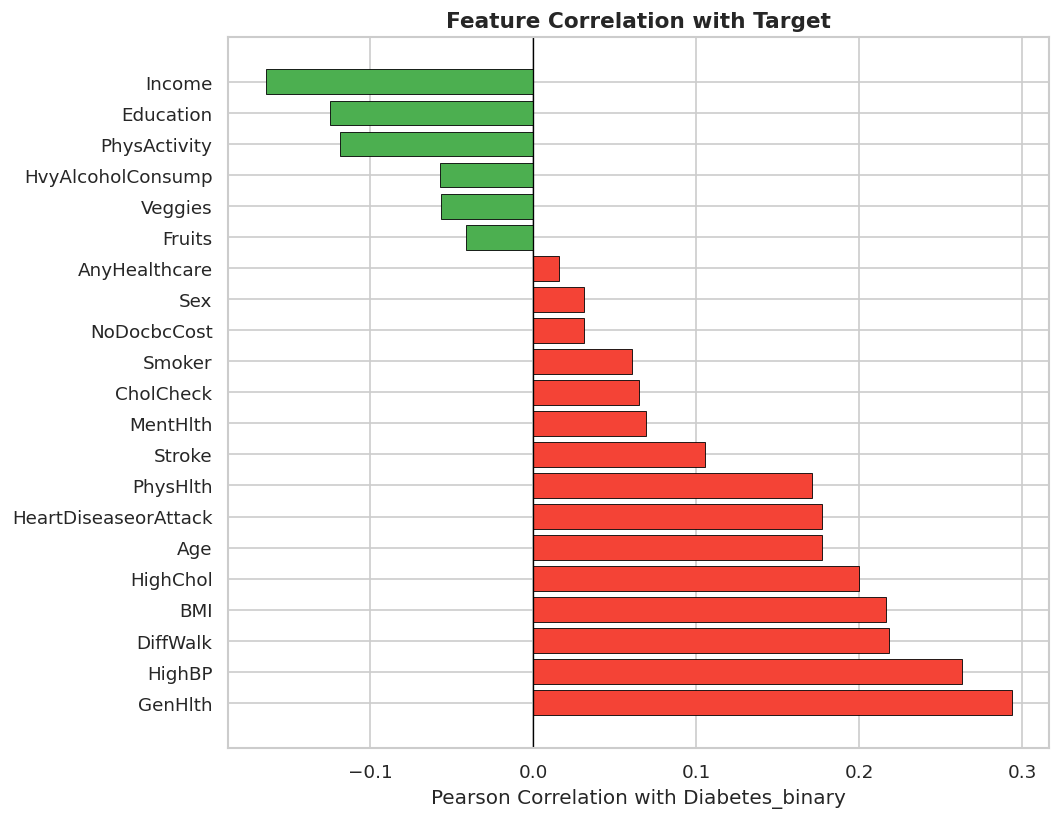

In [ ]:
target_corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
colors = ['#F44336' if v > 0 else '#4CAF50' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Diabetes_binary', fontsize=12)
ax.set_title('Feature Correlation with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_target_correlation.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing

Pipeline: remove duplicates → median imputation → 80/20 stratified split → StandardScaler (train-fit only) → SMOTE on training set only.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

TARGET = 'Diabetes_binary'
FEATURE_NAMES = [c for c in df.columns if c != TARGET]

X = df[FEATURE_NAMES].values
y = df[TARGET].values.astype(int)

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Train (after SMOTE): {X_train_res.shape}  |  Test: {X_test_scaled.shape}")
print(f"Class 0: {sum(y_train_res==0):,}  |  Class 1: {sum(y_train_res==1):,}")

Train (after SMOTE): (311002, 21)  |  Test: (45895, 21)
Class 0: 155,501  |  Class 1: 155,501


---
## 5. LightGBM Model

In [ ]:
lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.05,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)
print("LightGBM trained.")

LightGBM trained.


### 5.1 Threshold Tuning (F-beta, beta=1.5)

In [ ]:
lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]

prec_l, rec_l, thr_l = precision_recall_curve(y_test, lgbm_prob)
beta = 1.5
fb_l = (1 + beta**2) * (prec_l * rec_l) / ((beta**2 * prec_l) + rec_l + 1e-9)
best_idx_l = fb_l.argmax()
LGBM_THRESHOLD = thr_l[best_idx_l]
print(f"LightGBM optimal threshold: {LGBM_THRESHOLD:.4f}")

LightGBM optimal threshold: 0.1761


### 5.2 Evaluation

In [ ]:
lgbm_pred = (lgbm_prob >= LGBM_THRESHOLD).astype(int)

lgbm_acc  = accuracy_score(y_test, lgbm_pred)
lgbm_prec = precision_score(y_test, lgbm_pred)
lgbm_rec  = recall_score(y_test, lgbm_pred)
lgbm_f1   = f1_score(y_test, lgbm_pred)
lgbm_f2   = fbeta_score(y_test, lgbm_pred, beta=2)
lgbm_auc  = roc_auc_score(y_test, lgbm_prob)
lgbm_ap   = average_precision_score(y_test, lgbm_prob)

print("=" * 48)
print("  LIGHTGBM — EVALUATION RESULTS")
print("=" * 48)
print(f"  Threshold  : {LGBM_THRESHOLD:.4f}")
print(f"  Accuracy   : {lgbm_acc:.4f}")
print(f"  Precision  : {lgbm_prec:.4f}")
print(f"  Recall     : {lgbm_rec:.4f}")
print(f"  F1         : {lgbm_f1:.4f}")
print(f"  F2         : {lgbm_f2:.4f}")
print(f"  AUC-ROC    : {lgbm_auc:.4f}")
print(f"  Avg Prec   : {lgbm_ap:.4f}")
print("=" * 48)
print(classification_report(y_test, lgbm_pred, target_names=['No Diabetes', 'Diabetes']))

  LIGHTGBM — EVALUATION RESULTS
  Threshold  : 0.1761
  Accuracy   : 0.7063
  Precision  : 0.3164
  Recall     : 0.7928
  F1         : 0.4523
  F2         : 0.6093
  AUC-ROC    : 0.8180
  Avg Prec   : 0.4427
              precision    recall  f1-score   support

 No Diabetes       0.95      0.69      0.80     38876
    Diabetes       0.32      0.79      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895



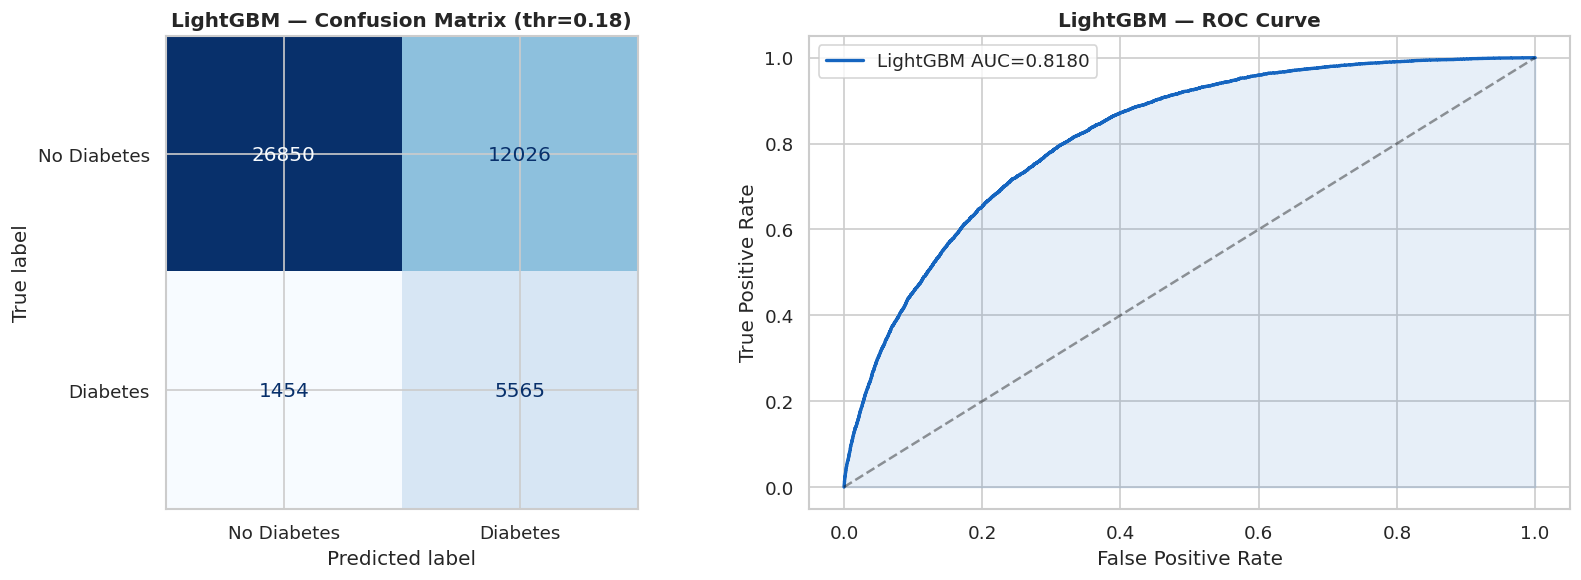

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, lgbm_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'LightGBM — Confusion Matrix (thr={LGBM_THRESHOLD:.2f})',
                  fontsize=12, fontweight='bold')

fpr_l, tpr_l, _ = roc_curve(y_test, lgbm_prob)
axes[1].plot(fpr_l, tpr_l, color='#1565C0', lw=2, label=f'LightGBM AUC={lgbm_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].fill_between(fpr_l, tpr_l, alpha=0.1, color='#1565C0')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('LightGBM — ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('04_lgbm_evaluation.png', bbox_inches='tight')
plt.show()

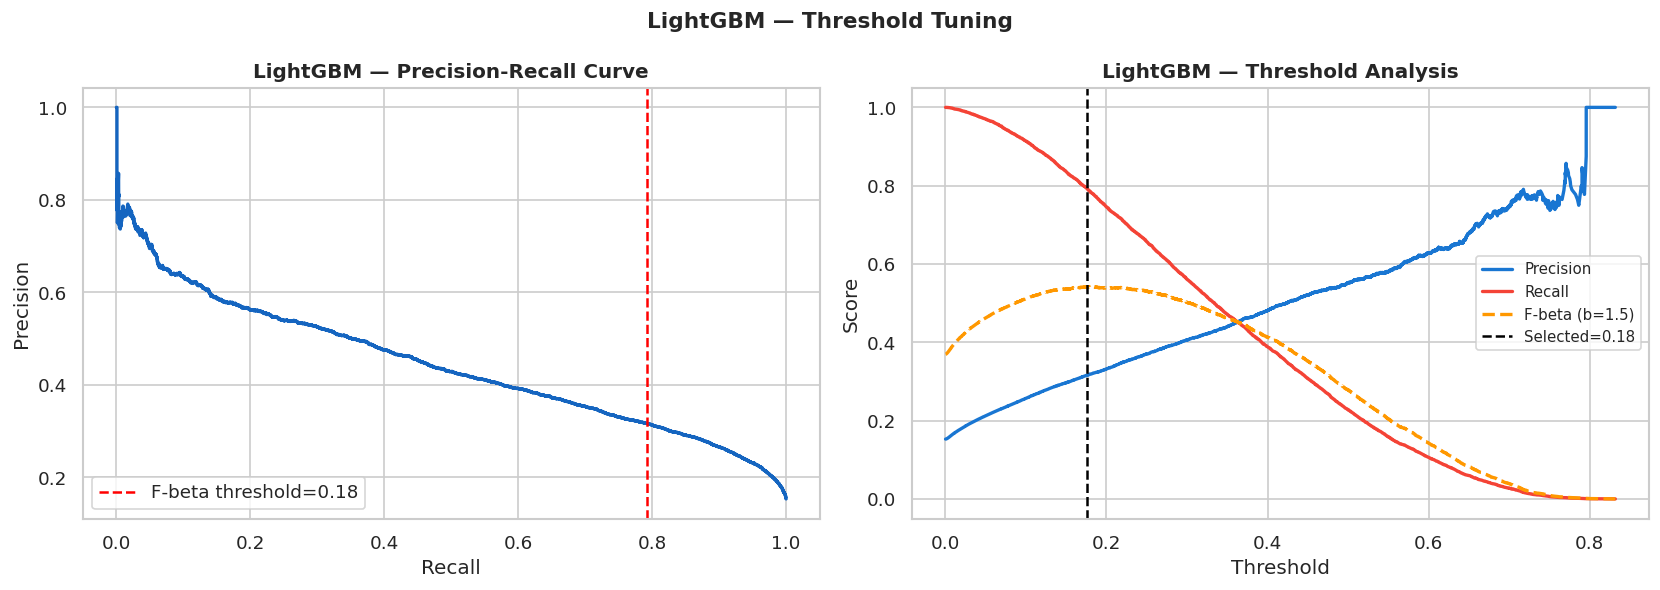

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_l[:-1], prec_l[:-1], color='#1565C0', lw=2)
axes[0].axvline(rec_l[best_idx_l], color='red', linestyle='--', lw=1.5,
                label=f'F-beta threshold={LGBM_THRESHOLD:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('LightGBM — Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].plot(thr_l, prec_l[:-1], color='#1976D2', lw=2, label='Precision')
axes[1].plot(thr_l, rec_l[:-1],  color='#F44336', lw=2, label='Recall')
axes[1].plot(thr_l, fb_l[:-1],   color='#FF9800', lw=2, linestyle='--',
             label=f'F-beta (b={beta})')
axes[1].axvline(LGBM_THRESHOLD, color='black', linestyle='--', lw=1.5,
                label=f'Selected={LGBM_THRESHOLD:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('LightGBM — Threshold Analysis', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
plt.suptitle('LightGBM — Threshold Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_lgbm_threshold.png', bbox_inches='tight')
plt.show()

In [ ]:
cv_lgbm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=50, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(cv_lgbm, X_train_scaled, y_train,
                         cv=skf, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(cv_lgbm, X_train_scaled, y_train,
                         cv=skf, scoring='f1', n_jobs=-1)
print(f"LightGBM 5-Fold CV  AUC: {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")
print(f"LightGBM 5-Fold CV  F1 : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")

LightGBM 5-Fold CV  AUC: 0.8140 +/- 0.0010
LightGBM 5-Fold CV  F1 : 0.4507 +/- 0.0026


### 5.3 XAI — LightGBM

#### SHAP

In [ ]:
print("Computing SHAP values for LightGBM...")
lgbm_explainer = shap.TreeExplainer(lgbm_model)

shap_n = 1000
shap_idx = np.random.choice(len(X_test_scaled), size=shap_n, replace=False)
X_shap_lgbm = pd.DataFrame(X_test_scaled[shap_idx], columns=FEATURE_NAMES)

lgbm_shap_vals = lgbm_explainer.shap_values(X_shap_lgbm)
if isinstance(lgbm_shap_vals, list):
    lgbm_sv = lgbm_shap_vals[1]
else:
    lgbm_sv = lgbm_shap_vals
print(f"SHAP computed on {shap_n} samples.")

Computing SHAP values for LightGBM...
SHAP computed on 1000 samples.


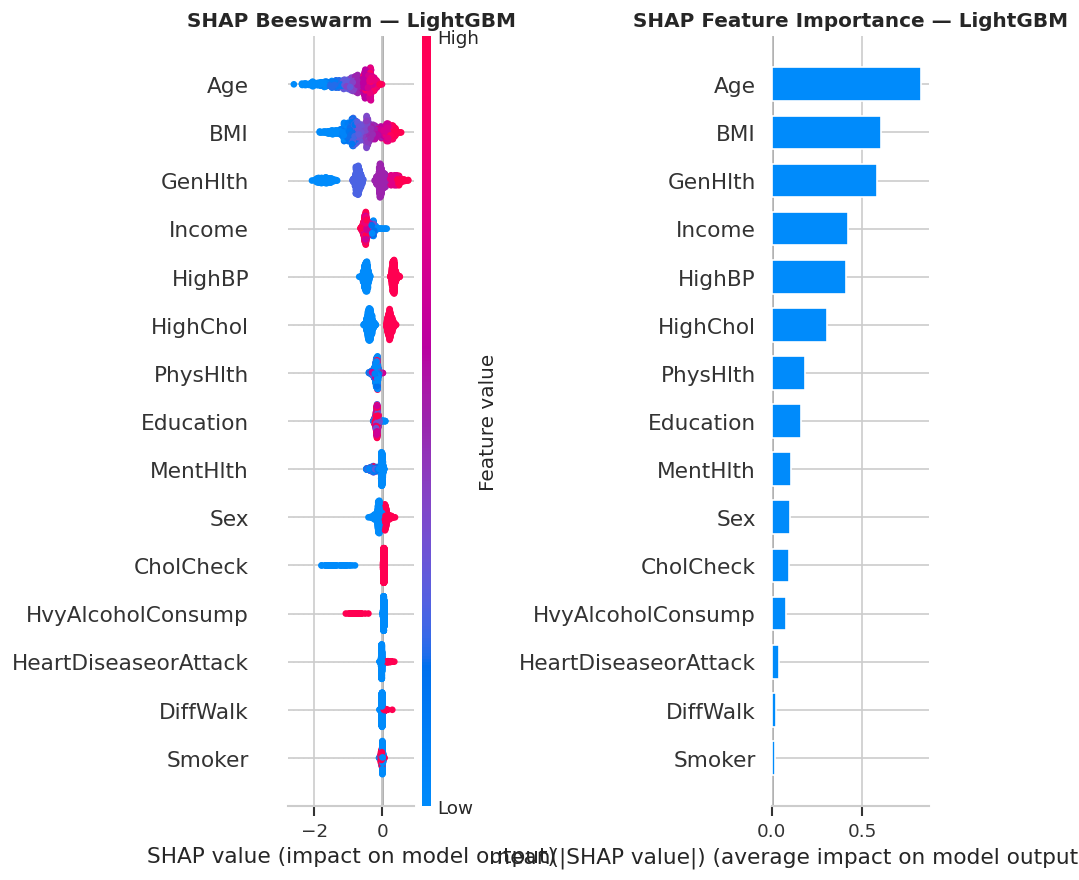

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(lgbm_sv, X_shap_lgbm, feature_names=FEATURE_NAMES,
                  plot_type='dot', show=False, max_display=15)
axes[0].set_title('SHAP Beeswarm — LightGBM', fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(lgbm_sv, X_shap_lgbm, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, max_display=15)
axes[1].set_title('SHAP Feature Importance — LightGBM', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('06_lgbm_shap_global.png', bbox_inches='tight')
plt.show()

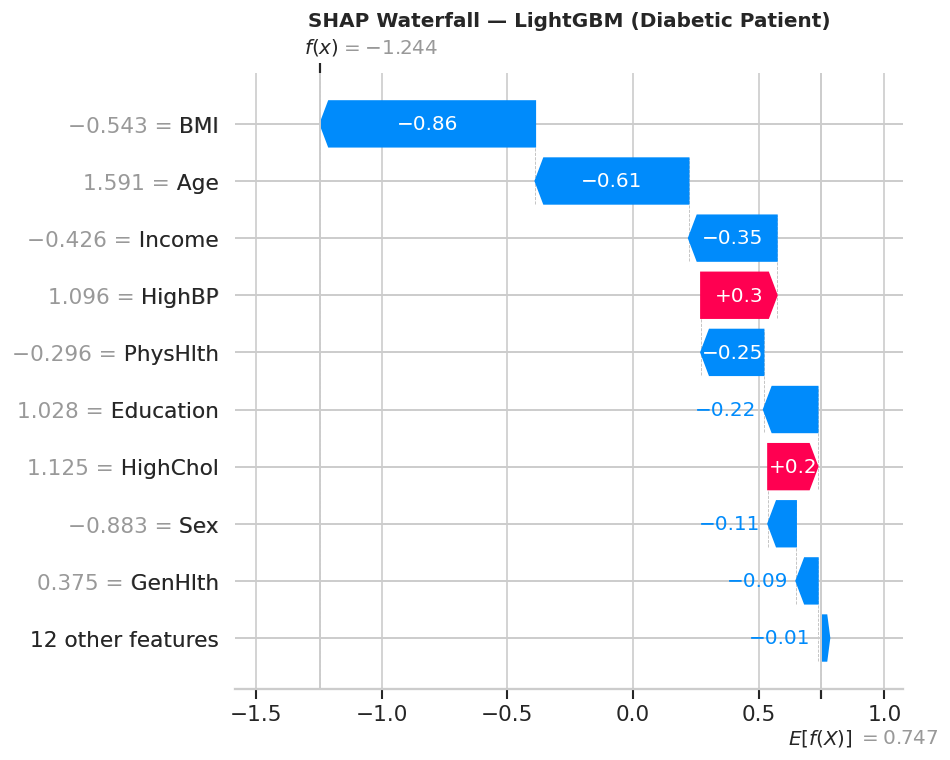

In [ ]:
exp_val = lgbm_explainer.expected_value
if isinstance(exp_val, list):
    exp_val = exp_val[1]

pos_in_shap = np.where(y_test[shap_idx] == 1)[0][0]
sv_single = lgbm_explainer(X_shap_lgbm.iloc[[pos_in_shap]])

shap.waterfall_plot(shap.Explanation(
    values=lgbm_sv[pos_in_shap],
    base_values=exp_val,
    data=X_shap_lgbm.iloc[pos_in_shap].values,
    feature_names=FEATURE_NAMES
), show=False)
plt.title('SHAP Waterfall — LightGBM (Diabetic Patient)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('07_lgbm_shap_waterfall.png', bbox_inches='tight')
plt.show()

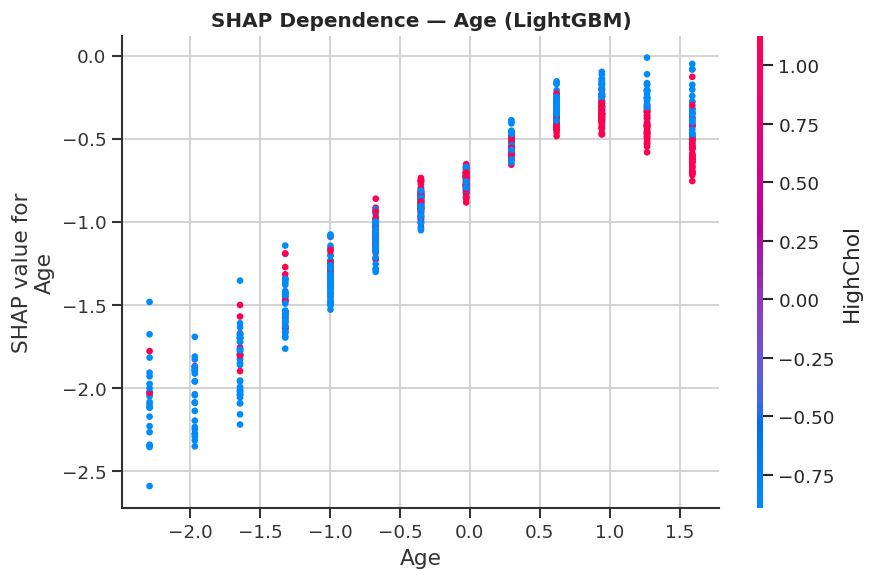

In [ ]:
top_feat_lgbm = pd.Series(np.abs(lgbm_sv).mean(axis=0), index=FEATURE_NAMES).idxmax()
shap.dependence_plot(top_feat_lgbm, lgbm_sv, X_shap_lgbm,
                     feature_names=FEATURE_NAMES, show=False)
plt.title(f'SHAP Dependence — {top_feat_lgbm} (LightGBM)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('08_lgbm_shap_dependence.png', bbox_inches='tight')
plt.show()

#### LIME — LightGBM

LIME LightGBM  P(No Diabetes)=0.402  P(Diabetes)=0.598


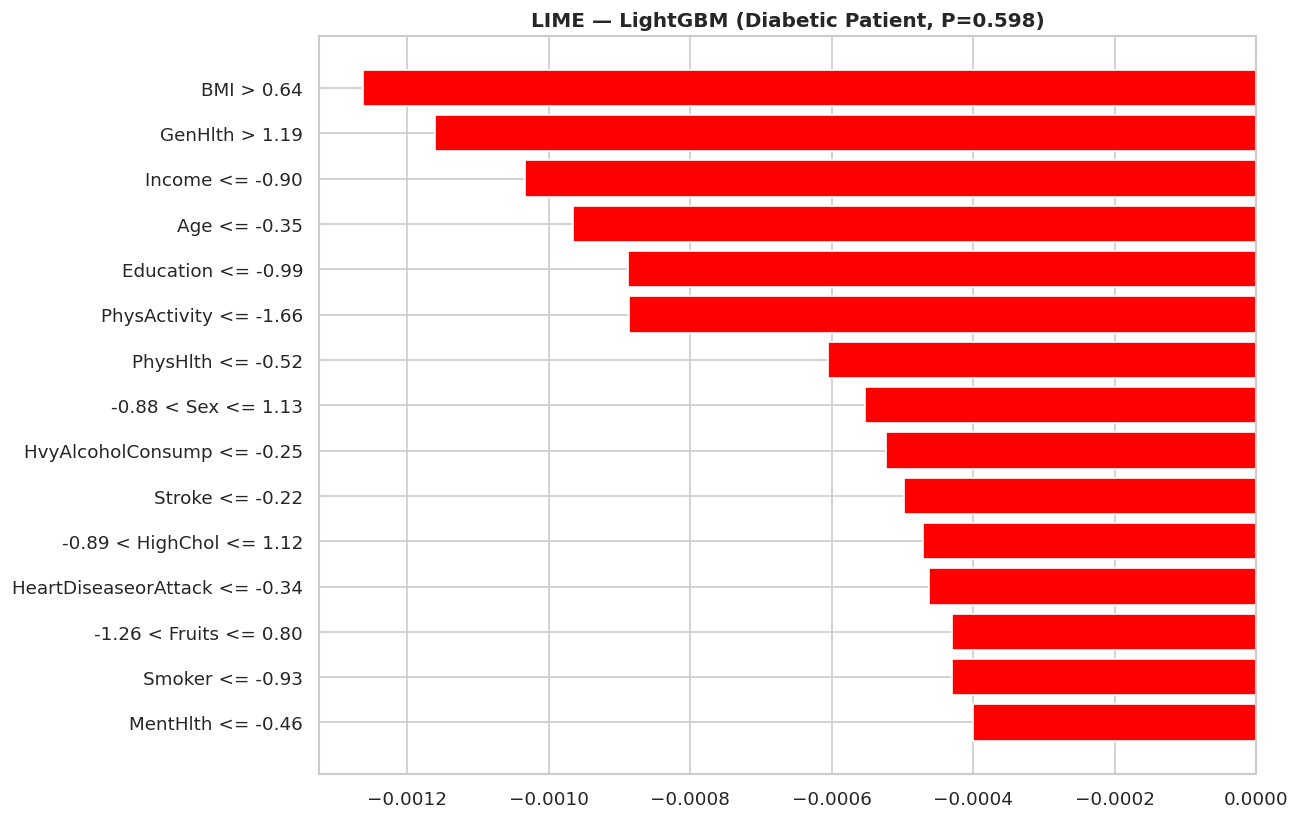

In [ ]:
lime_explainer_lgbm = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_res,
    feature_names=FEATURE_NAMES,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification',
    random_state=RANDOM_STATE
)

pos_idx_l = np.where(y_test == 1)[0][0]
lime_exp_l = lime_explainer_lgbm.explain_instance(
    data_row=X_test_scaled[pos_idx_l],
    predict_fn=lgbm_model.predict_proba,
    num_features=15,
    num_samples=2000
)
prob_l = lgbm_model.predict_proba([X_test_scaled[pos_idx_l]])[0]
print(f"LIME LightGBM  P(No Diabetes)={prob_l[0]:.3f}  P(Diabetes)={prob_l[1]:.3f}")

fig = lime_exp_l.as_pyplot_figure(label=1)
fig.set_size_inches(11, 7)
plt.title(f'LIME — LightGBM (Diabetic Patient, P={prob_l[1]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('09_lgbm_lime_single.png', bbox_inches='tight')
plt.show()

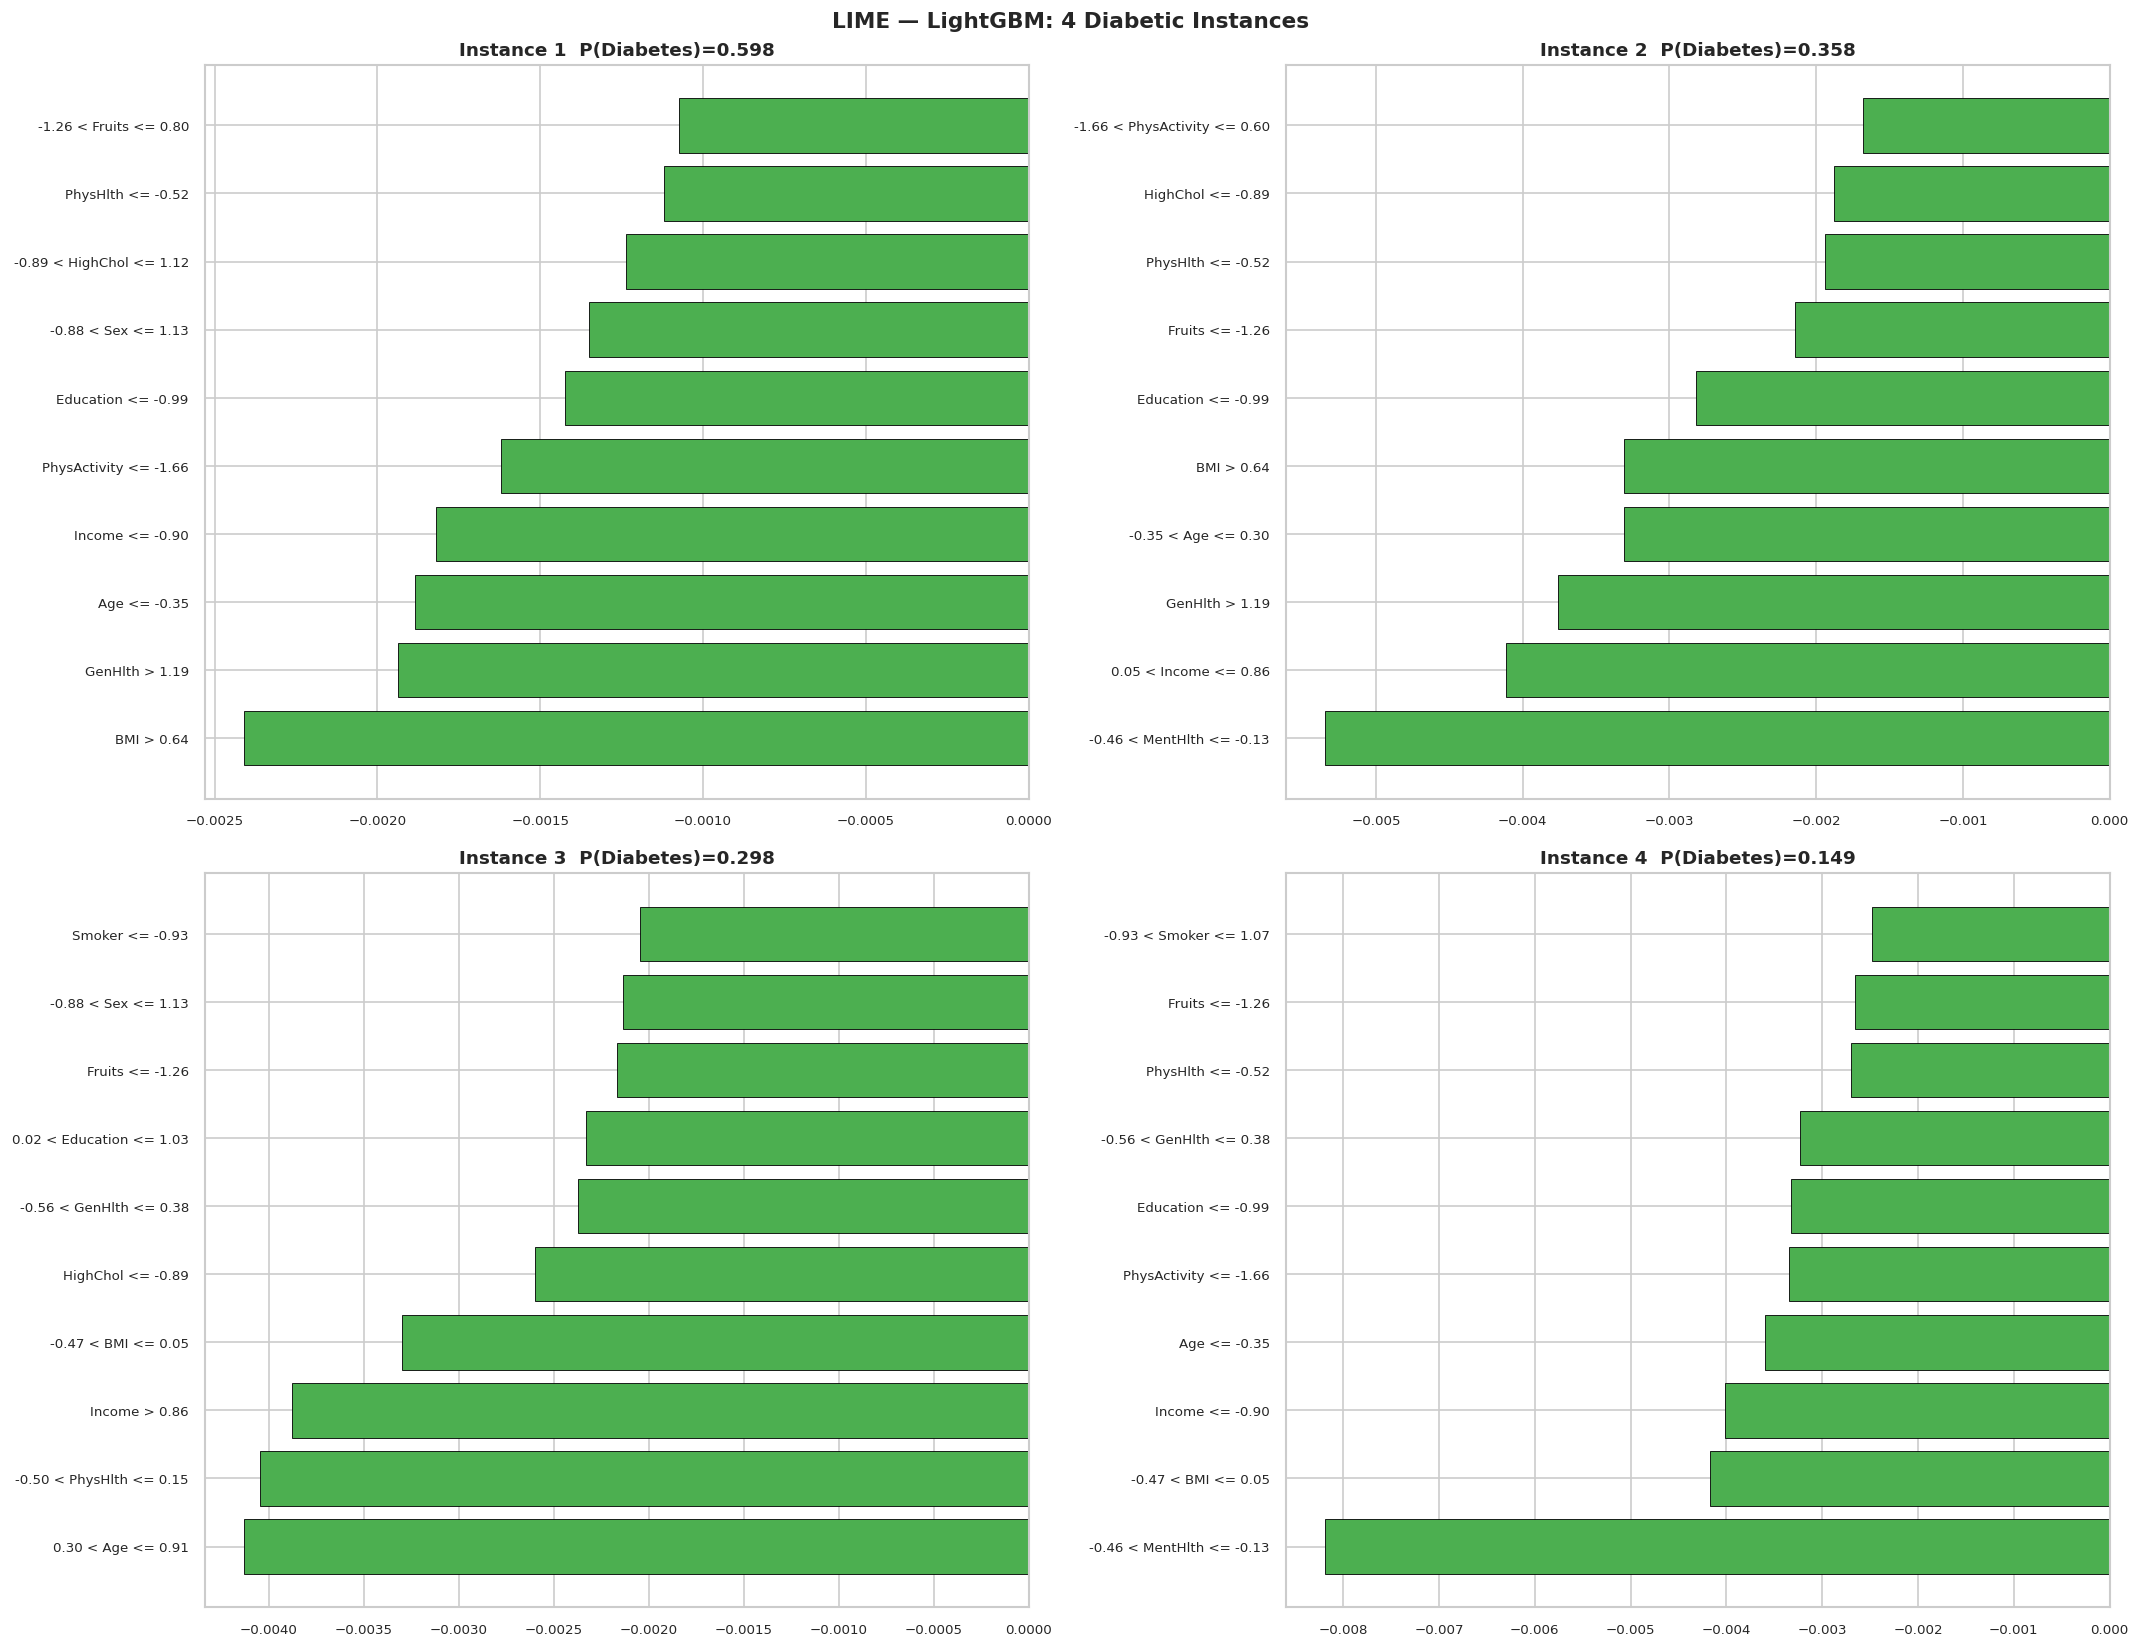

In [ ]:
pos_indices = np.where(y_test == 1)[0][:4]
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for i, idx in enumerate(pos_indices):
    inst = X_test_scaled[idx]
    exp = lime_explainer_lgbm.explain_instance(
        data_row=inst, predict_fn=lgbm_model.predict_proba,
        num_features=10, num_samples=1000
    )
    vals = exp.as_list(label=1)
    feats = [v[0] for v in vals]; weights = [v[1] for v in vals]
    colors = ['#F44336' if w > 0 else '#4CAF50' for w in weights]
    axes[i].barh(feats, weights, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].axvline(0, color='black', linewidth=0.8)
    prob = lgbm_model.predict_proba([inst])[0][1]
    axes[i].set_title(f'Instance {i+1}  P(Diabetes)={prob:.3f}', fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=8)
plt.suptitle('LIME — LightGBM: 4 Diabetic Instances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('10_lgbm_lime_multi.png', bbox_inches='tight')
plt.show()

#### Permutation Importance — LightGBM

Computing permutation importance for LightGBM (10 repeats)...


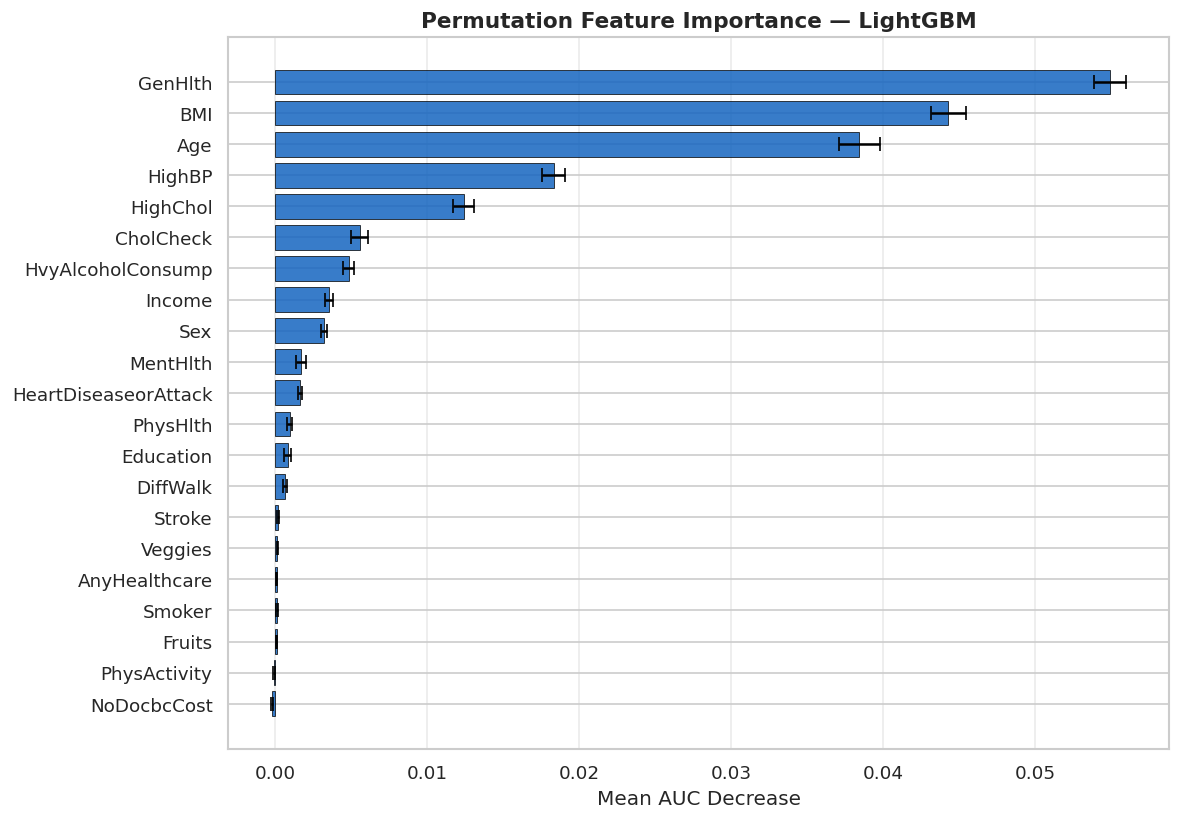

In [ ]:
print("Computing permutation importance for LightGBM (10 repeats)...")
perm_lgbm = permutation_importance(
    lgbm_model, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
)
pfi_lgbm = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': perm_lgbm.importances_mean,
    'Std'       : perm_lgbm.importances_std
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(pfi_lgbm['Feature'], pfi_lgbm['Importance'],
         xerr=pfi_lgbm['Std'], color='#1565C0', alpha=0.85,
         edgecolor='black', linewidth=0.5,
         error_kw={'elinewidth': 1.5, 'capsize': 4})
plt.xlabel('Mean AUC Decrease', fontsize=12)
plt.title('Permutation Feature Importance — LightGBM', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('11_lgbm_permutation.png', bbox_inches='tight')
plt.show()

#### Partial Dependence Plots — LightGBM

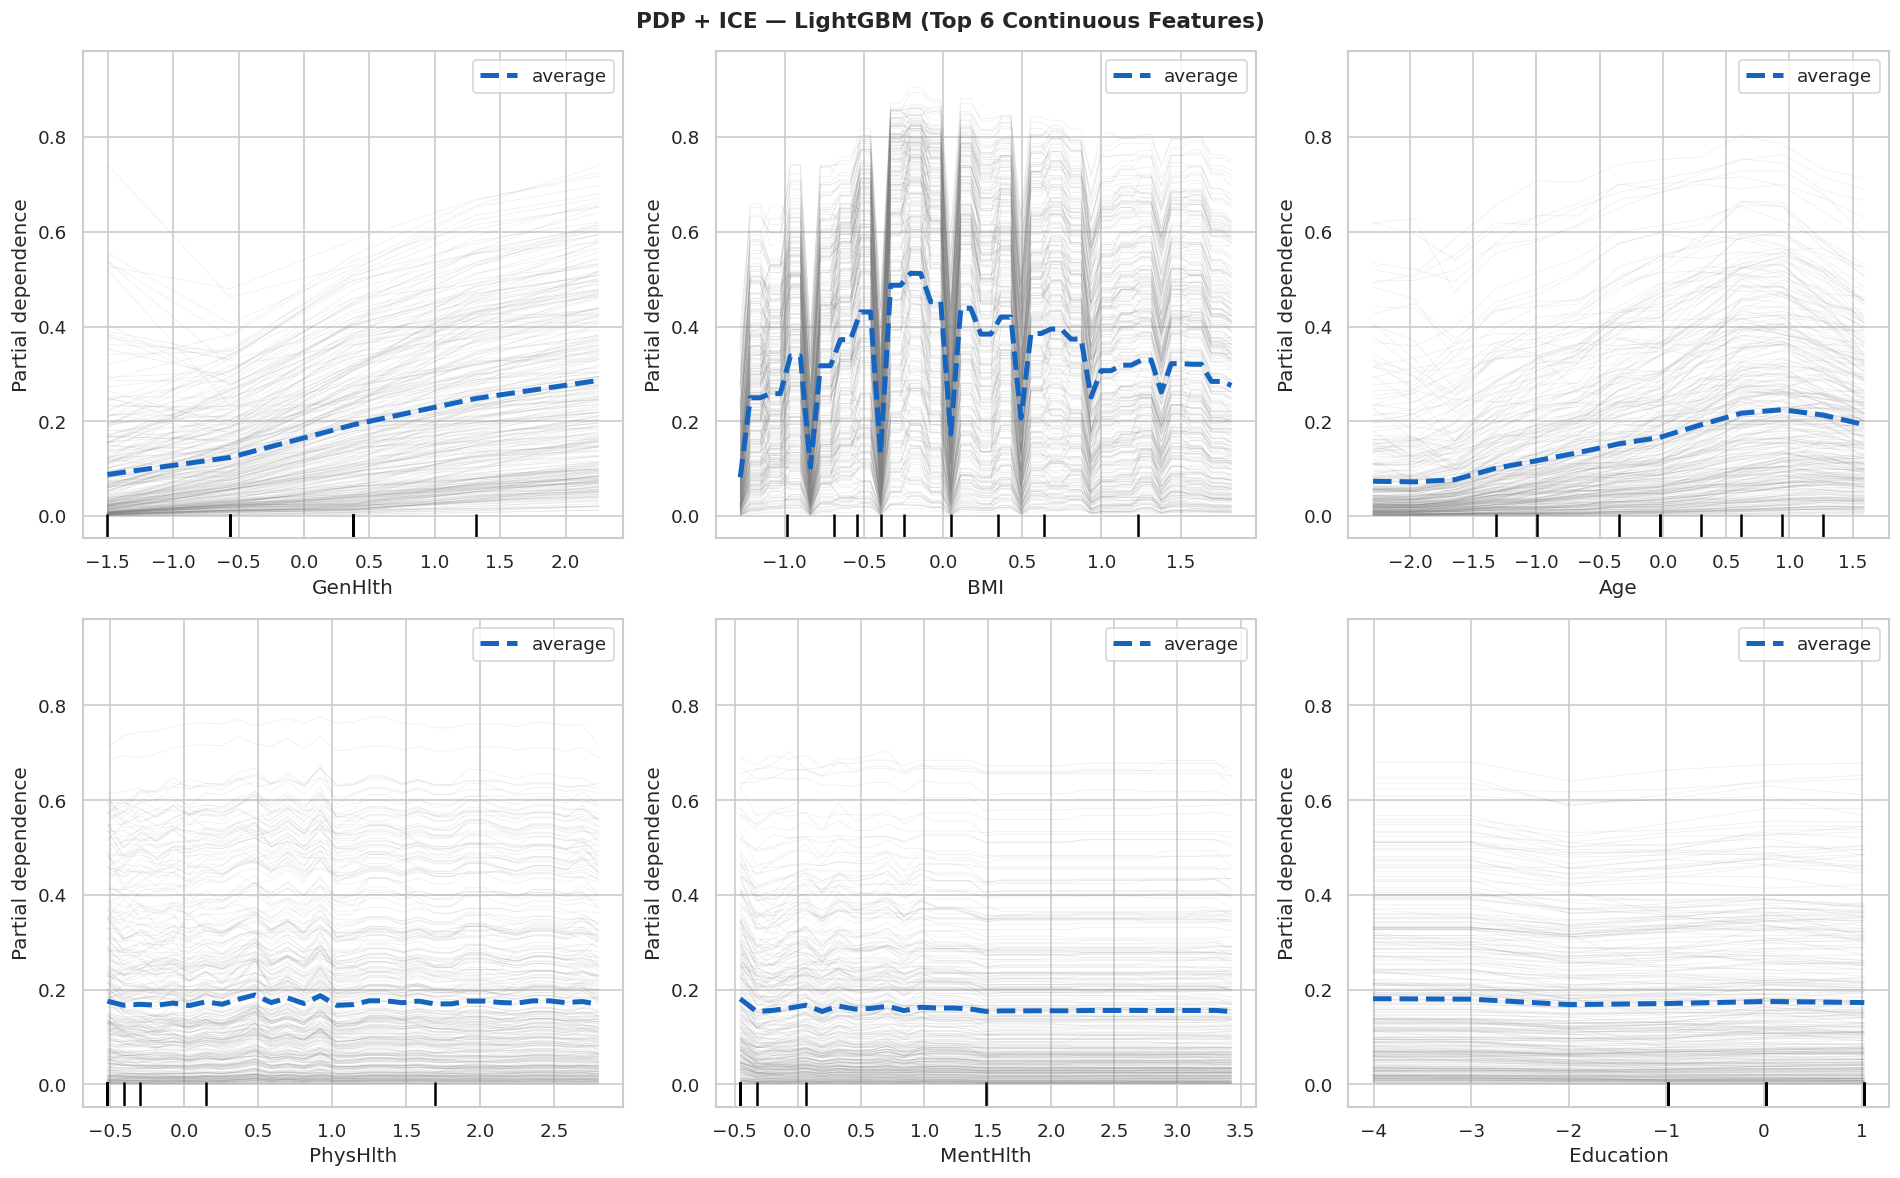

In [ ]:
continuous_features = ['GenHlth', 'BMI', 'Age', 'PhysHlth', 'MentHlth', 'Education']
top_feat_idx = [FEATURE_NAMES.index(f) for f in continuous_features]
X_test_df = pd.DataFrame(X_test_scaled, columns=FEATURE_NAMES)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
PartialDependenceDisplay.from_estimator(
    lgbm_model, X_test_df.values,
    features=top_feat_idx, feature_names=FEATURE_NAMES,
    kind='both', subsample=300, percentiles=(0.05, 0.95),
    grid_resolution=50, ax=axes.flatten(),
    ice_lines_kw={'color': 'grey', 'alpha': 0.12, 'linewidth': 0.5},
    pd_line_kw={'color': '#1565C0', 'linewidth': 3}
)
plt.suptitle('PDP + ICE — LightGBM (Top 6 Continuous Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('12_lgbm_pdp.png', bbox_inches='tight')
plt.show()

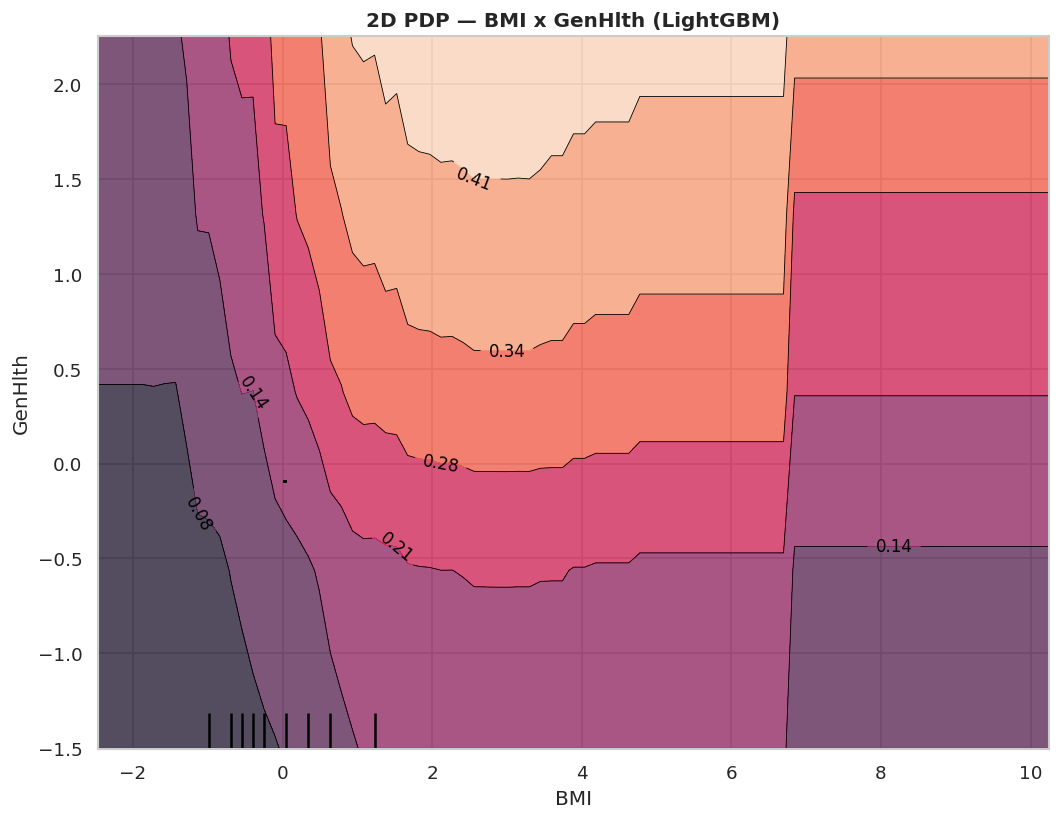

In [ ]:
bmi_idx = FEATURE_NAMES.index('BMI')
genhlth_idx = FEATURE_NAMES.index('GenHlth')
fig, ax = plt.subplots(figsize=(9, 7))
PartialDependenceDisplay.from_estimator(
    lgbm_model, X_test_df.values,
    features=[(bmi_idx, genhlth_idx)], feature_names=FEATURE_NAMES,
    kind='average', ax=ax
)
ax.set_title('2D PDP — BMI x GenHlth (LightGBM)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('13_lgbm_pdp_2d.png', bbox_inches='tight')
plt.show()